## 0. 환경 설정

필요한 라이브러리를 설치하고 불러옵니다.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from tqdm import tqdm

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

## 1. 데이터 로드 및 밀도(Sparsity) 확인

가장 먼저 데이터의 뼈대를 확인합니다. 데이터가 얼마나 비어있는지(희소성)를 숫자로 증명하여, 향후 다양한 구조적 접근이 왜 필요한지 논리를 세우는 단계입니다.

In [ ]:
source = 'Electronics'
# Clothing_Shoes_and_Jewelry / Electronics / Video_Games
file_path = f'../data/amazon/{source}_5.json'
save_dir = f'../results/{source}/eda'

print(f"데이터 로드 시작 (메모리 최적화 방식): {file_path}")

# 메모리를 적게 차지하도록 각각의 컬럼을 분리된 리스트로 저장
user_ids = []
item_ids = []
ratings = []
timestamps = []

# 파일의 총 라인 수를 모를 때도 메모리 터짐 없이 줄 단위로 읽기
with open(file_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Reading JSON lines"):
        # 딕셔너리를 통째로 저장하지 않고, 필요한 알맹이만 빼서 저장
        d = json.loads(line)
        user_ids.append(d['reviewerID'])
        item_ids.append(d['asin'])
        
        # 만약 값이 비어있을 경우를 대비한 안전 장치 (get)
        ratings.append(d.get('overall', 0))
        timestamps.append(d.get('unixReviewTime', 0))

# 가벼운 1차원 리스트들을 모아서 한 번에 DataFrame으로 변환
df = pd.DataFrame({
    'user_id': user_ids,
    'item_id': item_ids,
    'rating': ratings,
    'timestamp': timestamps
})

print(f"\n✅ 원본 데이터 형태: {df.shape}")

# 메모리 확보를 위해 사용이 끝난 임시 리스트 삭제
del user_ids, item_ids, ratings, timestamps

데이터 로드 시작 (메모리 최적화 방식): ../data/amazon/Clothing_Shoes_and_Jewelry_5.json


Reading JSON lines: 11285464it [01:07, 166001.93it/s]



✅ 원본 데이터 형태: (11285464, 4)


In [ ]:
# 2. 기본 통계 및 Sparsity 계산
num_users = df['user_id'].nunique()
num_items = df['item_id'].nunique()
num_interactions = len(df)

# 밀도 계산 = 실제 상호작용 수 / (전체 유저 수 * 전체 아이템 수)
density = num_interactions / (num_users * num_items)
sparsity = 1 - density

print(f"총 유저 수: {num_users:,}명")
print(f"총 아이템 수: {num_items:,}개")
print(f"총 리뷰(상호작용) 수: {num_interactions:,}건")
print(f"데이터 밀도(Density): {density:.6f} ({density*100:.4f}%)")
print(f"데이터 희소성(Sparsity): {sparsity*100:.4f}%")

총 유저 수: 1,219,678명
총 아이템 수: 376,858개
총 리뷰(상호작용) 수: 11,285,464건
데이터 밀도(Density): 0.000025 (0.0025%)
데이터 희소성(Sparsity): 99.9975%


In [ ]:
# 핵심 통계 수치를 txt 파일로 기록
stats_file_path = os.path.join(save_dir, '00_basic_stats.txt')

with open(stats_file_path, 'w', encoding='utf-8') as f:
    f.write(f"[{source} 데이터셋 EDA 요약]\n")
    f.write(f"- 총 유저 수: {num_users:,}명\n")
    f.write(f"- 총 아이템 수: {num_items:,}개\n")
    f.write(f"- 총 리뷰 수: {num_interactions:,}건\n")
    f.write(f"- 데이터 밀도(Density): {density:.6f} ({density*100:.4f}%)\n")
    f.write(f"- 데이터 희소성(Sparsity): {sparsity*100:.4f}%\n")

print(f"저장 완료: {stats_file_path}")

저장 완료: ../results/Clothing_Shoes_and_Jewelry/eda\00_basic_stats.txt


## 2. 인기도 편중 현상 (Popularity Skewness) 확인

특정 소수 상품에 리뷰가 몰려있는지 확인합니다. 추천 시스템이 인기 상품만 반복해서 보여주는 편중 현상을 방지하고, 
유저에게 균형 있고 다양한 발견을 제공하기 위해 반드시 짚고 넘어가야 할 지점입니다.

상위 10% 아이템이 전체 리뷰의 60.41%를 차지함
상위 20% 아이템이 전체 리뷰의 72.77%를 차지함
저장 완료: ../results/Clothing_Shoes_and_Jewelry/eda\01_long_tail_distribution.png


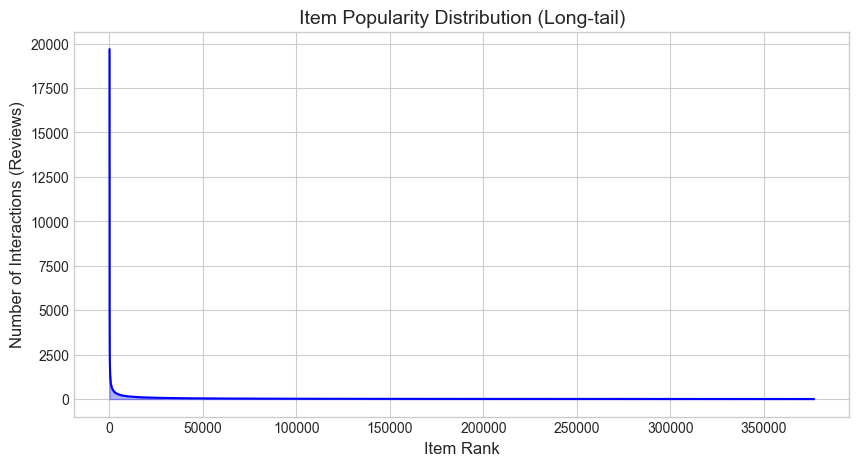

In [ ]:
# 아이템별 리뷰 수 계산 및 내림차순 정렬
item_interaction_counts = df.groupby('item_id').size().sort_values(ascending=False)

# 상위 10%, 20% 아이템이 전체 상호작용의 몇 %를 차지하는지 계산
top_10_percent = int(len(item_interaction_counts) * 0.1)
top_20_percent = int(len(item_interaction_counts) * 0.2)

interaction_top_10 = item_interaction_counts.iloc[:top_10_percent].sum() / num_interactions
interaction_top_20 = item_interaction_counts.iloc[:top_20_percent].sum() / num_interactions

print(f"상위 10% 아이템이 전체 리뷰의 {interaction_top_10*100:.2f}%를 차지함")
print(f"상위 20% 아이템이 전체 리뷰의 {interaction_top_20*100:.2f}%를 차지함")

# 롱테일 분포 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(item_interaction_counts.values, color='b')
plt.fill_between(range(len(item_interaction_counts)), item_interaction_counts.values, alpha=0.3, color='b')
plt.title('Item Popularity Distribution (Long-tail)', fontsize=14)
plt.xlabel('Item Rank', fontsize=12)
plt.ylabel('Number of Interactions (Reviews)', fontsize=12)
save_path_longtail = os.path.join(save_dir, '01_long_tail_distribution.png')
plt.savefig(save_path_longtail, dpi=300, bbox_inches='tight')
print(f"저장 완료: {save_path_longtail}")

plt.show()

## 3. 유저의 시퀀스 길이 (Sequence Length) 파악

SASRec과 같은 시퀀셜 모델을 구동할 수 있는 조건이 되는지 확인합니다. 
과거의 흐름을 파악하려면 유저당 어느 정도의 누적된 이력이 있어야 합니다.

저장 완료: ../results/Clothing_Shoes_and_Jewelry/eda\02_sequence_length_distribution.png


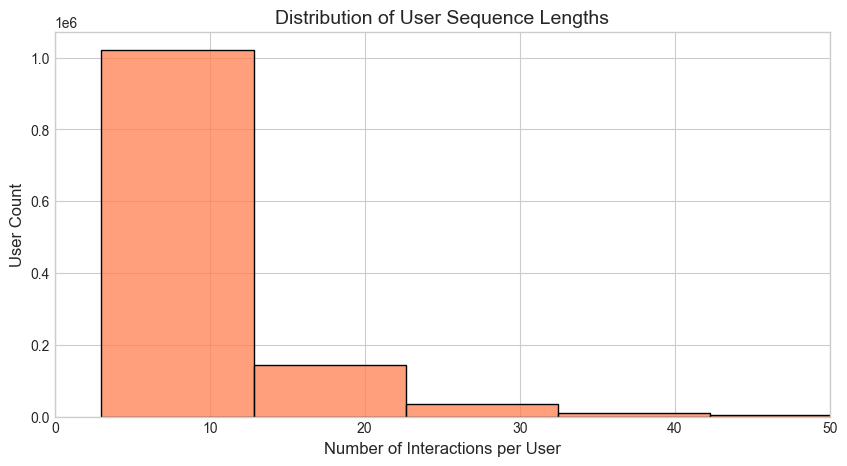


[유저별 리뷰 수 통계]
count    1.219678e+06
mean     9.252822e+00
std      7.321460e+00
min      3.000000e+00
25%      5.000000e+00
50%      7.000000e+00
75%      1.000000e+01
max      4.940000e+02
dtype: float64


In [ ]:
# 유저별 리뷰 작성 수 분포 확인
user_interaction_counts = df.groupby('user_id').size()

plt.figure(figsize=(10, 5))
sns.histplot(user_interaction_counts, bins=50, kde=False, color='coral')
plt.title('Distribution of User Sequence Lengths', fontsize=14)
plt.xlabel('Number of Interactions per User', fontsize=12)
plt.ylabel('User Count', fontsize=12)

# 너무 긴 시퀀스를 가진 아웃라이어 때문에 그래프가 안 보일 수 있으므로 x축 제한 (예: 50건 이하만 표시)
plt.xlim(0, 50)
save_path_seq = os.path.join(save_dir, '02_sequence_length_distribution.png')
plt.savefig(save_path_seq, dpi=300, bbox_inches='tight')
print(f"저장 완료: {save_path_seq}")

plt.show()

print("\n[유저별 리뷰 수 통계]")
print(user_interaction_counts.describe())